<a href="https://colab.research.google.com/github/AlbertPuentes/Deep-Learning-week8_Actvidad_8./blob/main/Actividad_8_Modelo_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clasificación de Imágenes: CNN desde cero vs Transfer Learning

El propósito de este notebook es evidenciar el flujo completo de un proyecto de Deep Learning para visión computacional.
Comparamos dos enfoques sobre el dataset CIFAR-10:
1. Una red neuronal convolucional (CNN) construida y entrenada desde cero.
2. Una arquitectura de Transfer Learning utilizando MobileNetV2 preentrenada en ImageNet.


In [5]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
from tensorflow.keras.applications import MobileNetV2
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

# 1. CARGA DE DATOS
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

# 2. NORMALIZACIÓN
# Imágenes con píxeles entre 0 y 255. Normalización al rango [0, 1]
train_images, test_images = train_images / 255.0, test_images / 255.0

# Nombres de las clases para las visualizaciones
class_names = ['Avión', 'Auto', 'Pájaro', 'Gato', 'Ciervo',
               'Perro', 'Rana', 'Caballo', 'Barco', 'Camión']

print(f"Formato de imágenes de entrenamiento: {train_images.shape}")
print(f"Formato de etiquetas de entrenamiento: {train_labels.shape}")

Formato de imágenes de entrenamiento: (50000, 32, 32, 3)
Formato de etiquetas de entrenamiento: (50000, 1)


## Modelo 1: CNN Base
Con una arquitectura de capas convolucionales, extracción de características seguidas de Max Pooling, reducción de dimensionalidad y capas densas.

Entrenando Modelo Base...
Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 77s 96ms/step - accuracy: 0.4144 - loss: 1.6033 - val_accuracy: 0.5166 - val_loss: 1.3560
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 68s 87ms/step - accuracy: 0.5537 - loss: 1.2537 - val_accuracy: 0.5907 - val_loss: 1.1530
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 78s 82ms/step - accuracy: 0.6094 - loss: 1.1069 - val_accuracy: 0.5791 - val_loss: 1.2006
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 78s 99ms/step - accuracy: 0.6447 - loss: 1.0073 - val_accuracy: 0.6532 - val_loss: 0.9798
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 74s 94ms/step - accuracy: 0.6734 - loss: 0.9325 - val_accuracy: 0.6578 - val_loss: 0.9818
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 74s 84ms/step - accuracy: 0.6930 - loss: 0.8768 - val_accuracy: 0.6778 - val_loss: 0.9354
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 62s 80ms/step - accuracy: 0.7093 - loss: 0.8269 - val_accuracy: 0.6899 - val_loss: 0.8938
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 80s 78ms/step - accuracy

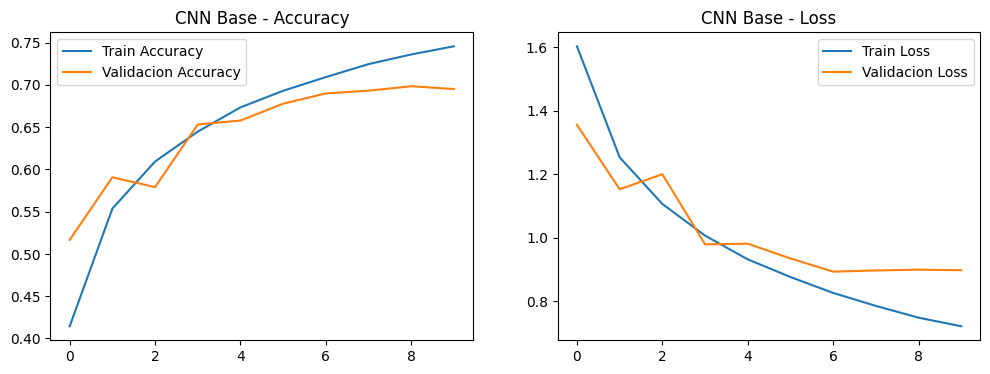

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step


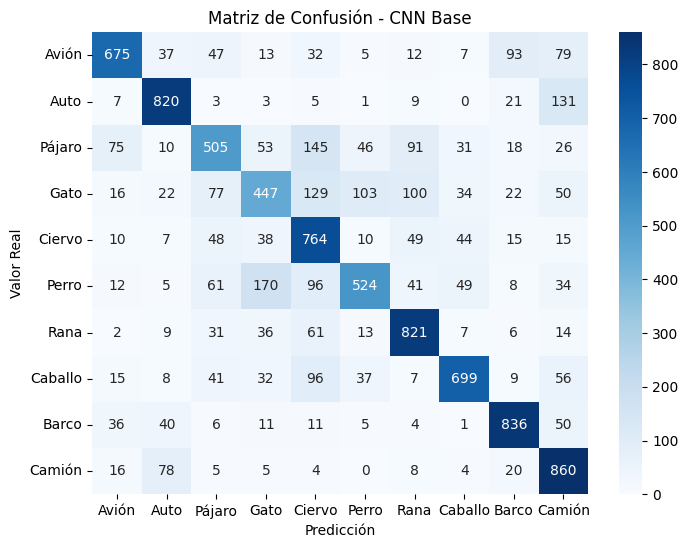

In [10]:
# Definición de la arquitectura
model_base = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_base.compile(optimizer='adam',
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])

# Entrenamiento
print("Entrenando Modelo Base...")
history_base = model_base.fit(train_images, train_labels, epochs=10,
                              validation_data=(test_images, test_labels),
                              batch_size=64)


# Función para graficar Modelo CNN Base
def plot_history(history, title):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validacion Accuracy')
    plt.title(f'{title} - Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validacion Loss')
    plt.title(f'{title} - Loss')
    plt.legend()
    plt.show()

plot_history(history_base, "CNN Base")

# Matriz de Confusión
y_pred_base = np.argmax(model_base.predict(test_images), axis=1)
cm_base = confusion_matrix(test_labels, y_pred_base)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_base, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión - CNN Base')
plt.show()



## Modelo 2: Transfer Learning

Para escenarios donde el dataset es limitado, puede hacerse uso de una red preentrenada en un dataset, "ImageNet".
Se coongela la base convolucional de MobileNetV2 entrenando una nueva cabeza clasificadora.

/tmp/ipykernel_1536/4218452342.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model_tl = MobileNetV2(input_shape=(32, 32, 3),


Entrenando Modelo Transfer Learning...
Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 63s 69ms/step - accuracy: 0.2872 - loss: 1.9673 - val_accuracy: 0.3176 - val_loss: 1.8809
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 51s 65ms/step - accuracy: 0.3226 - loss: 1.8616 - val_accuracy: 0.3361 - val_loss: 1.8443
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 102s 90ms/step - accuracy: 0.3366 - loss: 1.8295 - val_accuracy: 0.3396 - val_loss: 1.8255
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 80s 102ms/step - accuracy: 0.3453 - loss: 1.8082 - val_accuracy: 0.3432 - val_loss: 1.8129
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 68s 84ms/step - accuracy: 0.3504 - loss: 1.7909 - val_accuracy: 0.3418 - val_loss: 1.8045
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 70s 68ms/step - accuracy: 0.3535 - loss: 1.7784 - val_accuracy: 0.3534 - val_loss: 1.8001
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 58s 74ms/step - accuracy: 0.3559 - loss: 1.7691 - val_accuracy: 0.3490 - val_loss: 1.7924
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 78s 70ms/

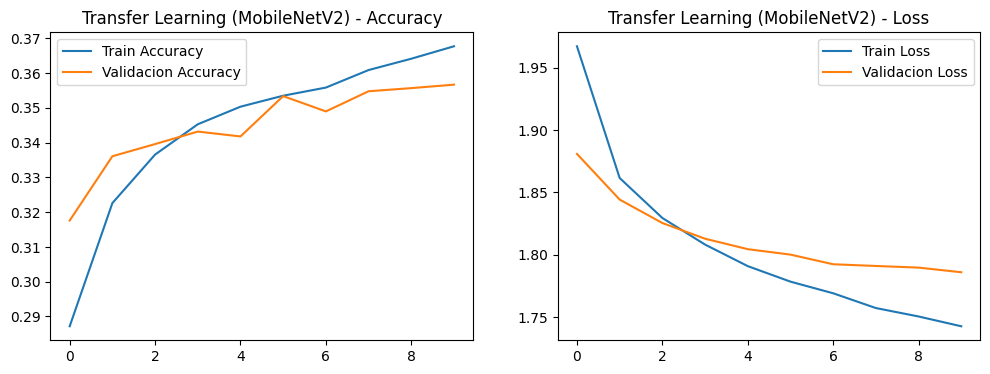

In [11]:
# Cargar MobileNetV2 sin las capas densas finales (include_top=False)
base_model_tl = MobileNetV2(input_shape=(32, 32, 3),
                            include_top=False,
                            weights='imagenet')

# Congelar la base para no perder los pesos preentrenados
base_model_tl.trainable = False

# Construir el nuevo modelo encima de la base
model_tl = models.Sequential([
    base_model_tl,
    layers.GlobalAveragePooling2D(), # Alternativa más eficiente a Flatten
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2), # Previene overfitting
    layers.Dense(10, activation='softmax')
])

model_tl.compile(optimizer='adam',
                 loss='sparse_categorical_crossentropy',
                 metrics=['accuracy'])

print("Entrenando Modelo Transfer Learning...")
history_tl = model_tl.fit(train_images, train_labels, epochs=10,
                          validation_data=(test_images, test_labels),
                          batch_size=64)

plot_history(history_tl, "Transfer Learning (MobileNetV2)")

##  Conclusiones

Tras ejecutar ambos modelos bajo condiciones controladas cada uno para 10 épocas, mismo optimizador, mismo tamaño de lote, se observo lo siguiente:

### 1. ¿Qué mejoró y qué se mantuvo?
* **Velocidad de convergencia:** El modelo de Transfer Learning suele arrancar con una precisión inicial mucho más alta en la primera época porque ya tiene datos, por otro lado el modelo CNN base tiene que aprender a detectar bordes desde cero.
* **Precisión general (Accuracy):** Dependiendo de las épocas, el modelo base puede llegar entre un 65-70%. El modelo preentrenado suele ser más robusto a la validación temprana, aunque MobileNetV2 le cueste un poco ya que los pesos fueron optimizados para imágenes de 224x224, y se paso imágenes mas pequeñas de (32x32).

### 2. Trade-offs (Costo-Beneficio)
* **CNN:**
 *  *ventajas:* Es un modelo ligero, tiene pocos parámetros y hace inferencias deforma rapida.
 * *Desventajas:* Tarda más en aprender y es muy propenso al *sobreajuste* (overfitting) si no se le aplican técnicas de regularización.
* **Transfer Learning:**
 * *Ventajas:* Generaliza mucho mejor gracias al conocimiento previo de ImageNet. Ahorra tiempo de cómputo masivo y es ideal cuando hay pocas imágenes locales.
 * *DAesventajas:* El modelo es mucho más pesado (incluso MobileNet que es eficiente, tiene millones de parámetros). Requiere más RAM y tiempo de carga.

### 3. Recomendaciones
Se evidencio que proyectos con datos limitados, **Transfer Learning** es el mas adecuado. Para mejorar el rendimiento de este modelo , el siguiente una opcion a aplicar seria el *Fine-Tuning*: descongelar las últimas capas convolucionales de MobileNetV2 y entrenarlas con una tasa de aprendizaje muy baja para adaptar los pesos preentrenados específicamente a las texturas.